# Superstore Sales Analysis

## Objective
Analyze order volume and sub-category demand across states and compare their profitability against the highest-profit sub-category–state combination.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("SuperStoreOrders1.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

## Data Overview
The dataset contains retail transaction data including order details, product categories, sub-categories, sales, profit, and geographic information at the state level.


In [4]:
cols = ['sales', 'profit', 'quantity']

df[cols] = (
    df[cols]
    .replace(',', '', regex=True)
    .apply(pd.to_numeric)
)

In [5]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True, errors='coerce')
df['ship_date']  = pd.to_datetime(df['ship_date'],  format='mixed', dayfirst=True, errors='coerce')

In [6]:
df = df.dropna(subset=['order_date'])

## Data Cleaning
- Converted numeric fields stored as strings (e.g., values with thousands separators)
- Standardized mixed date formats
- Ensured consistent data types for analysis


In [7]:
df_base = df.copy()

In [8]:
top_states = (
    df_base.groupby('state')['order_id']
           .nunique()
           .sort_values(ascending=False)
           .head(3)
)

top_states


state
California    1021
England        699
New York       562
Name: order_id, dtype: int64

In [9]:
top_state_names = top_states.index.tolist()
top_state_names


['California', 'England', 'New York']

In [10]:
top_ordered_sub = (
    df_base[df_base['state'].isin(top_state_names)]
    .groupby(['state', 'sub_category'])['quantity']
    .sum()
    .reset_index()
    .sort_values(['state', 'quantity'], ascending=[True, False])
    .groupby('state')
    .first()
)

top_ordered_sub

,sub_category,quantity
state,,
California,Paper,1091
England,Art,771
New York,Binders,696


## Top 3 States by Order Volume
The following states place the highest number of orders, indicating strong customer demand.

In [11]:
profit_rows = []

for state in top_ordered_sub.index:
    sub_cat = top_ordered_sub.loc[state, 'sub_category']
    
    profit = df_base[
        (df_base['state'] == state) &
        (df_base['sub_category'] == sub_cat)
    ]['profit'].sum()
    
    profit_rows.append({
        'state': state,
        'sub_category': sub_cat,
        'profit': profit
    })

top_state_sub_profit = pd.DataFrame(profit_rows)
top_state_sub_profit

,state,sub_category,profit
0,California,Paper,7977.5395
1,England,Art,3740.5110
2,New York,Binders,11096.0260


## Profitability of Top Sub-Categories
Although these sub-categories are ordered most frequently, their total profit and profit margins vary significantly.

In [13]:
best_sub_state = (
    df_base.groupby(['state', 'sub_category'])['profit']
           .sum()
           .reset_index()
           .sort_values('profit', ascending=False)
           .head(3)
)

best_sub_state

,state,sub_category,profit
6418,New York,Machines,17320.0762
2875,England,Bookcases,15783.6030
2877,England,Copiers,15009.6210


## Top 3 States by Profit (Sub-Category Level)
Although these sub-categories are ordered most frequently, their total profit and profit margins vary significantly.

In [14]:
comparison = pd.concat([
    top_state_sub_profit,
    best_sub_state
], ignore_index=True)

comparison

,state,sub_category,profit
0,California,Paper,7977.5395
1,England,Art,3740.5110
2,New York,Binders,11096.0260
3,New York,Machines,17320.0762
4,England,Bookcases,15783.6030
5,England,Copiers,15009.6210


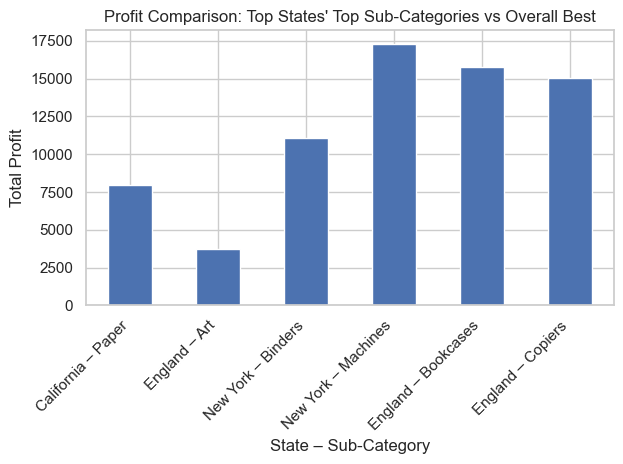

In [18]:
comparison['label'] = (
    comparison['state'] + ' – ' + comparison['sub_category']
)

comparison.set_index('label')['profit'].plot(kind='bar')
plt.title("Profit Comparison: Top States' Top Sub-Categories vs Overall Best")
plt.ylabel("Total Profit")
plt.xlabel("State – Sub-Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Benchmark: Highest-Profit Sub-Category Overall
To assess whether high demand aligns with profitability, the results were compared against the highest-profit sub-category–state combination across the entire dataset.


## Key Insights
- High order volume does not necessarily translate into high profitability.
- The most frequently ordered sub-categories in top-ordering states exhibit lower profit margins.
- Sub-categories with fewer orders can generate higher margins due to pricing.


## Conclusion
The analysis shows that focusing solely on order volume may overlook more profitable opportunities. Strategic emphasis on high-margin sub-categories and regional product mix optimization can improve overall profitability.


In [19]:
df_base.to_csv("cleaned_superstore_data1.csv", index=False)